<a href="https://colab.research.google.com/github/PDM-15/AML-2026/blob/master/25.08.2026/diabetes_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preprocessing - Diabetes dataset

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Loading
drive.mount('/content/drive')

data = pd.read_csv("drive/My Drive/Dataset/diabetes.csv")
dataset = data

#to check the dataset
data.info()

#to split the dataset, identifying dependent and independent variables
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 45)

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Decision tree

[[104  26]
 [ 29  33]]
Accuracy: 71.35416666666666 %

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       130
           1       0.56      0.53      0.55        62

    accuracy                           0.71       192
   macro avg       0.67      0.67      0.67       192
weighted avg       0.71      0.71      0.71       192
 

User is not diabetic


[Text(0.49357745398773006, 0.9642857142857143, 'x[1] <= 0.186\ngini = 0.459\nsamples = 576\nvalue = [370, 206]'),
 Text(0.1875, 0.8928571428571429, 'x[7] <= -0.406\ngini = 0.305\nsamples = 357\nvalue = [290, 67]'),
 Text(0.340538726993865, 0.9285714285714286, 'True  '),
 Text(0.05521472392638037, 0.8214285714285714, 'x[5] <= 0.097\ngini = 0.13\nsamples = 200\nvalue = [186.0, 14.0]'),
 Text(0.024539877300613498, 0.75, 'x[0] <= 1.07\ngini = 0.016\nsamples = 126\nvalue = [125, 1]'),
 Text(0.012269938650306749, 0.6785714285714286, 'gini = 0.0\nsamples = 125\nvalue = [125, 0]'),
 Text(0.03680981595092025, 0.6785714285714286, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.08588957055214724, 0.75, 'x[6] <= 1.107\ngini = 0.29\nsamples = 74\nvalue = [61, 13]'),
 Text(0.06134969325153374, 0.6785714285714286, 'x[5] <= 1.699\ngini = 0.23\nsamples = 68\nvalue = [59, 9]'),
 Text(0.049079754601226995, 0.6071428571428571, 'x[6] <= 0.07\ngini = 0.19\nsamples = 66\nvalue = [59, 7]'),
 Text(0.024539

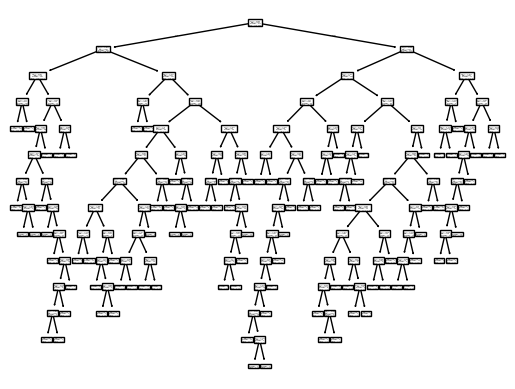

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics
from sklearn import tree

#Decision tree object of DecisionTreeClassifier class
classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 45) #We can give gini as criterion as well
classifier.fit(X_train, y_train)


y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

#print(y_test)
#print(y_pred)
print(cm)

prediction = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", prediction * 100, "%\n")

print(classification_report(y_test, y_pred), "\n")

new_individual = np.array([[2, 127, 80, 60, 0, 35, 0.391, 35]])
new_individual_scaled = sc_X.transform(new_individual)
prediction = classifier.predict(new_individual_scaled)

if prediction[0] == 1:
  print("User is diabetic \n")
else:
  print("User is not diabetic \n")

tree.plot_tree(classifier)